# 00 — Executive summary
### Olist Brazilian E-Commerce · `retail-platform-analytics`

**Start here.** This is the top-level summary of the project — read it first for the headline on each
theme, then follow the links into the deep-dive notebooks for the full analysis.

**What this is about.** [Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) is
Brazil's largest department-store marketplace, connecting thousands of small sellers to customers
across the country. This project models ~100k of its orders (2016–2018) with dbt on Snowflake; the
sections below distil the four deep-dives into the handful of findings a stakeholder needs. Every
number is computed live from the dbt marts.

*By design this summary keeps the **code light and the explanations high-level** — the full code
walkthroughs, methodology, and caveats live in notebooks `01`–`04`.*

| Read this for the headline | Go deeper in |
|---|---|
| Growth, scale, and where revenue comes from | [`01` exploratory analysis](01_exploratory_analysis.ipynb) |
| Why customers are satisfied (or not) | [`02` delivery & satisfaction](02_delivery_and_satisfaction.ipynb) |
| Who the customers are (and why RFM fails) | [`03` customer value & behavior](03_customer_value_and_behavior.ipynb) |
| Where margin leaks | [`04` category & freight economics](04_category_and_freight_economics.ipynb) |

*Dataset: ~100k orders, Sep 2016 – Oct 2018. Trend charts use the reliable window **Jan 2017 – Aug
2018** (the edge months are data ramp-in/cutoff, not real demand).*

## Setup

In [1]:
# db.py (the shared Snowflake helper) lives in this analysis/ folder, so add it to the path.
import sys
sys.path.insert(0, ".")
import db

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")   # consistent look across all notebooks
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    """Run SQL on Snowflake and return a DataFrame with lowercased column names
    (Snowflake returns columns uppercase; lowercasing keeps the analysis code tidy)."""
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

## 1. The platform at a glance

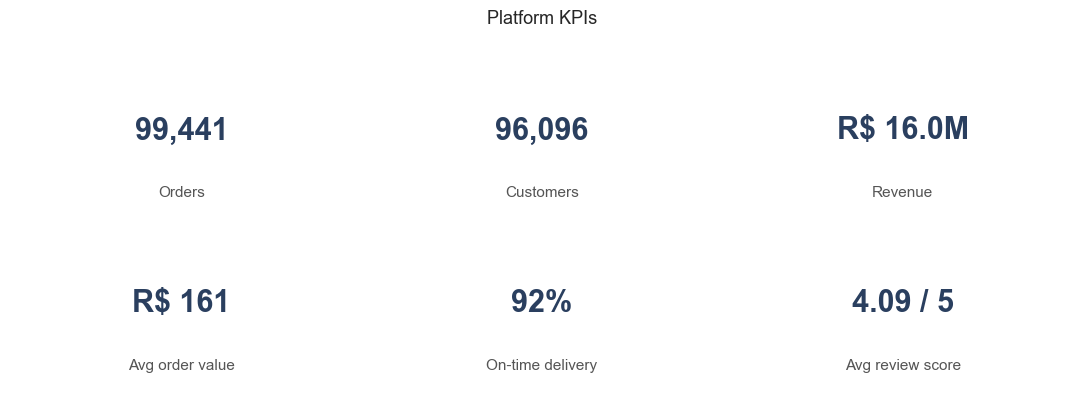

In [2]:
# Headline KPIs in a single pass over the orders fact table.
kpi = q('''
    select count(*)                                as orders,
           count(distinct customer_id)            as customers,
           sum(total_payment_value)               as revenue,
           avg(total_payment_value)               as aov,             -- average order value
           avg(iff(status = 'delivered', 1, 0)) * 100 as delivered_pct,
           avg(review_score)                      as avg_review
    from dev_marts.fct_orders
''').iloc[0]
# On-time rate is only meaningful for orders that were actually delivered.
on_time = q("select avg(iff(is_delivered_on_time,1,0))*100 p from dev_marts.fct_orders "
            "where status='delivered' and is_delivered_on_time is not null").iloc[0, 0]

# Format each KPI as a display string for the "card" dashboard below.
cards = [
    ("Orders", f"{kpi['orders']:,.0f}"),
    ("Customers", f"{kpi['customers']:,.0f}"),
    ("Revenue", f"R$ {kpi['revenue']/1e6:,.1f}M"),   # /1e6 -> millions of reais
    ("Avg order value", f"R$ {kpi['aov']:,.0f}"),
    ("On-time delivery", f"{on_time:.0f}%"),
    ("Avg review score", f"{kpi['avg_review']:.2f} / 5"),
]
# Render as a 2x3 grid of text "cards" (no axes) for a clean KPI banner.
fig, axes = plt.subplots(2, 3, figsize=(11, 4))
for ax, (label, val) in zip(axes.ravel(), cards):
    ax.axis("off")
    ax.text(0.5, 0.62, val, ha="center", va="center", fontsize=22, fontweight="bold", color="#2A3F5F")
    ax.text(0.5, 0.22, label, ha="center", va="center", fontsize=11, color="#555")
fig.suptitle("Platform KPIs", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

**~100k orders and R$16M in revenue** from a two-year run, 97% delivered, at a healthy ~4.1★
average. A solid, functioning marketplace — the questions below are about *quality of growth*, not
survival.

## 2. Growth story

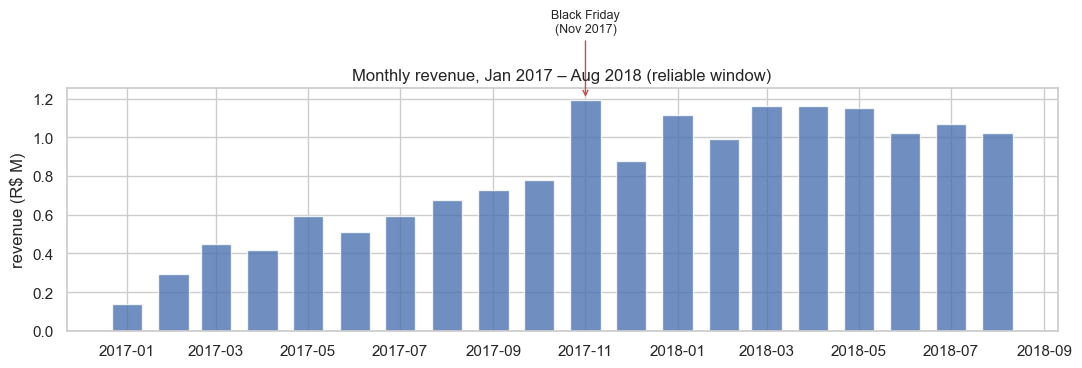

In [3]:
# Monthly revenue over the reliable window only (the partial edge months would show fake collapses).
monthly = q('''
    select date_trunc('month', purchased_at)::date as month,
           count(*) as orders, sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where purchased_at >= '2017-01-01' and purchased_at < '2018-09-01'
    group by 1 order by 1
''')
# Snowflake ::date comes back as Python date objects (object dtype); cast to datetime so the
# equality check for the Black Friday bar below matches (and the x-axis renders as dates).
monthly["month"] = pd.to_datetime(monthly["month"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly["month"], monthly["revenue"] / 1e6, width=20, color="#4C72B0", alpha=0.8)
# Annotate the Nov-2017 bar — Brazil's Black Friday and the single biggest month.
bf = monthly.loc[monthly["month"] == pd.Timestamp("2017-11-01")]
if len(bf):
    ax.annotate("Black Friday\n(Nov 2017)", xy=(bf["month"].iloc[0], bf["revenue"].iloc[0] / 1e6),
                xytext=(bf["month"].iloc[0], bf["revenue"].iloc[0] / 1e6 + 0.35),
                ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_title("Monthly revenue, Jan 2017 – Aug 2018 (reliable window)")
ax.set_ylabel("revenue (R$ M)")
plt.tight_layout(); plt.show()

**Strong, decelerating growth.** Monthly volume roughly quadrupled across 2017 and settled at a
~R$1M/month run-rate in 2018, with a clear **Black Friday** spike (Nov 2017). Quarter-on-quarter growth
cooled from +76% early to low single digits as the base matured — a maturing business, not a stalling
one. *(Detail: `01`.)*

## 3. The satisfaction lever — deliver on time

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_56935/2087591515.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rev, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])


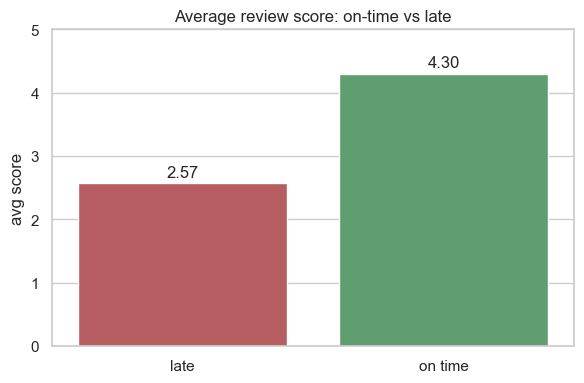

In [4]:
# Average review score split by whether the order arrived on time (delivered orders with a review).
rev = q('''
    select is_delivered_on_time, count(*) as orders, avg(review_score) as avg_score
    from dev_marts.fct_orders
    where status='delivered' and review_score is not null and is_delivered_on_time is not null
    group by 1 order by 1
''')
rev["label"] = rev["is_delivered_on_time"].map({True: "on time", False: "late"})

fig, ax = plt.subplots(figsize=(6, 4))
# Red = late, green = on time, to reinforce the message.
sns.barplot(data=rev, x="label", y="avg_score", ax=ax, palette=["#C44E52", "#55A868"])
ax.set_ylim(0, 5); ax.set_title("Average review score: on-time vs late"); ax.set_xlabel(""); ax.set_ylabel("avg score")
for i, r in rev.iterrows():
    ax.text(i, r["avg_score"] + 0.1, f"{r['avg_score']:.2f}", ha="center")
plt.tight_layout(); plt.show()

**The single biggest driver of satisfaction is on-time delivery.** On-time orders average
**4.30★**; late orders collapse to **2.57★** — a 1.7-point swing that holds after controlling for
distance, weight, and category. Delivery reliability, not price or product, is what customers rate.
*(Detail: `02`.)*

## 4. Who the customers are — acquisition, not loyalty

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_56935/2572264875.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier, x="tier", y="rev_share", ax=ax, palette=["#8FB0D6", "#4C72B0", "#2A3F5F"])


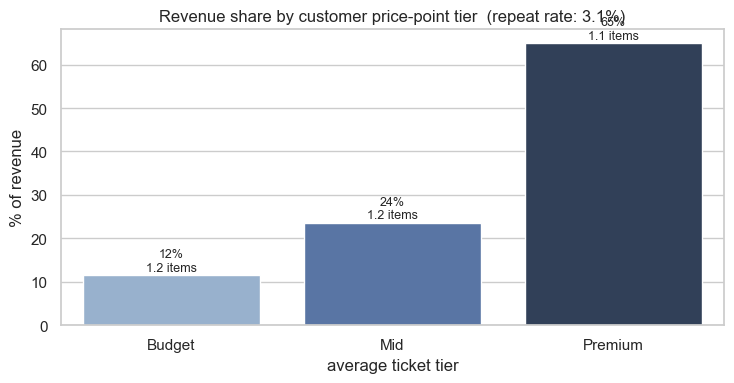

value~ticket corr 0.90  vs  value~quantity corr 0.23


In [5]:
# Almost all customers buy once, so value isn't about frequency or basket size — it's about the
# price-point of what they buy. Pull per-customer orders, items, spend, and average ticket.
cust = q('''
    select o.customer_id,
           count(distinct oi.order_id) as n_orders,
           count(*)                    as n_items,
           sum(oi.total_item_value)    as total_value,
           avg(oi.price)               as avg_ticket
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    group by 1
''')
for c in ["n_orders", "n_items", "total_value", "avg_ticket"]:
    cust[c] = pd.to_numeric(cust[c], errors="coerce")
repeat_pct = 100 * (cust["n_orders"] >= 2).mean()             # ~3% ever order twice
corr_ticket = cust["total_value"].corr(cust["avg_ticket"])   # value tracks ticket...
corr_qty = cust["total_value"].corr(cust["n_items"])         # ...far more than quantity

# Group customers into equal thirds by average ticket, then look at revenue share per tier.
cust["tier"] = pd.qcut(cust["avg_ticket"].rank(method="first"), 3, labels=["Budget", "Mid", "Premium"])
tier = cust.groupby("tier", observed=True).agg(
    revenue=("total_value", "sum"), avg_items=("n_items", "mean")).reset_index()
tier["rev_share"] = 100 * tier["revenue"] / tier["revenue"].sum()

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(data=tier, x="tier", y="rev_share", ax=ax, palette=["#8FB0D6", "#4C72B0", "#2A3F5F"])
ax.set_title(f"Revenue share by customer price-point tier  (repeat rate: {repeat_pct:.1f}%)")
ax.set_xlabel("average ticket tier"); ax.set_ylabel("% of revenue")
for i, r in tier.iterrows():
    # avg items annotated too — it stays ~flat across tiers, i.e. value is ticket, not quantity.
    ax.text(i, r["rev_share"] + 1, f"{r['rev_share']:.0f}%\n{r['avg_items']:.1f} items", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"value~ticket corr {corr_ticket:.2f}  vs  value~quantity corr {corr_qty:.2f}")

**Customer value is about *what* they buy, not *how often*.** Olist is a one-and-done marketplace —
only ~3% of customers ever buy twice, and ~90% of orders are single-item — so there's no frequency or
basket behaviour to segment on. What *does* vary is **ticket size**: total value tracks average item
price (corr ≈0.90) far more than item count (≈0.23). Grouped by price-point, the **premium third of
customers drives ~65% of revenue** while buying no more items than anyone else — they just buy pricier
things (watches, health & beauty, computers). So growing customer value is an **acquisition &
merchandising** lever — attract customers into high-ticket categories — not a loyalty one.
*(Detail: `03`.)*

## 5. Where margin leaks — freight drag by category

/var/folders/f2/481mvzmd5yb221yj12xj5fcw0000gn/T/ipykernel_56935/2667712827.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="category_name", x="freight_pct", ax=ax, palette=colors)


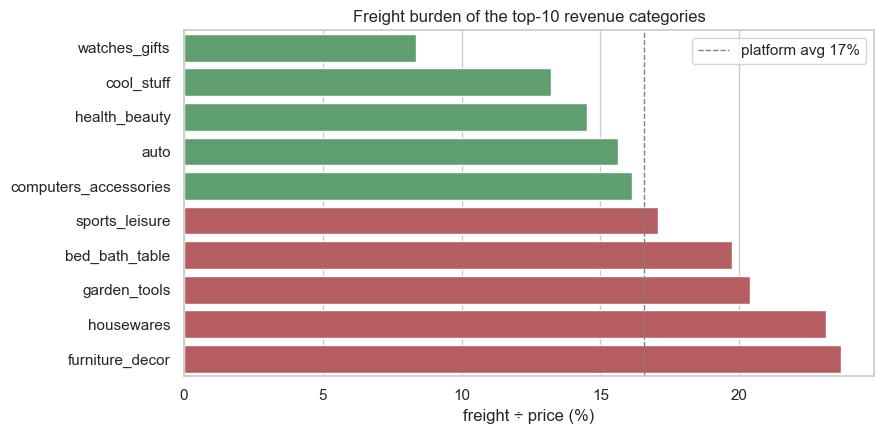

In [6]:
# Freight burden = freight as a % of item price, per category (our proxy for margin pressure).
cat = q('''
    select oi.category_name, count(*) as items, sum(oi.total_item_value) as revenue,
           100.0 * sum(oi.freight_value) / sum(oi.price) as freight_pct
    from dev_marts.fct_order_items oi
    where oi.category_name is not null
    group by 1 having count(*) >= 300          -- ignore tiny categories with noisy averages
''')
overall = q("select 100.0*sum(freight_value)/sum(price) p from dev_marts.fct_order_items").iloc[0, 0]
# Show the 10 biggest categories by revenue, sorted by their freight burden.
top = cat.sort_values("revenue", ascending=False).head(10).sort_values("freight_pct")

fig, ax = plt.subplots(figsize=(9, 4.5))
# Red bars = above the platform-average burden (margin risk), green = below.
colors = ["#C44E52" if p > overall else "#55A868" for p in top["freight_pct"]]
sns.barplot(data=top, y="category_name", x="freight_pct", ax=ax, palette=colors)
ax.axvline(overall, color="grey", ls="--", lw=1, label=f"platform avg {overall:.0f}%")
ax.set_title("Freight burden of the top-10 revenue categories"); ax.set_xlabel("freight ÷ price (%)"); ax.set_ylabel("")
ax.legend()
plt.tight_layout(); plt.show()

**Freight eats ~17% of sale value on average — but unevenly.** Bulky home categories
(`bed_bath_table`, `furniture_decor`, `housewares`) and cheap electronics run 20–29%, squeezing margin;
high-ticket `watches_gifts` and `health_beauty` stay margin-safe (~8–15%). Two fixes: **logistics** for
the bulky lines, **pricing/basket rules** for the cheap-and-light ones. *(Detail: `04`.)*

## 6. Where the business is — geographic concentration

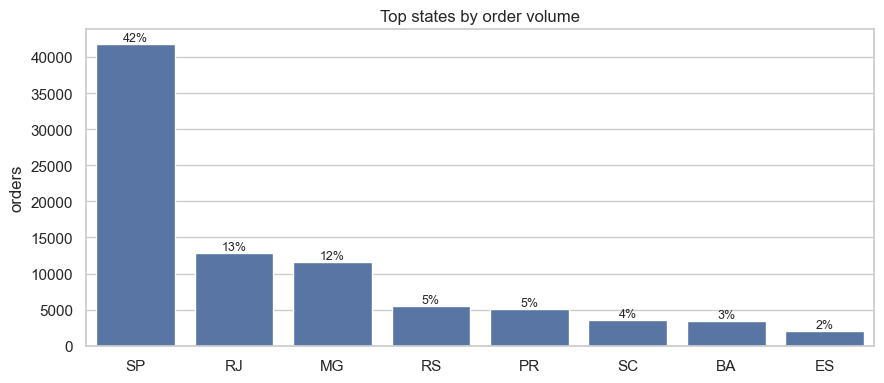

In [7]:
# Order volume by delivery state (top 8), with each state's share of all orders.
geo = q('''
    select delivery_state as state, count(*) as orders
    from dev_marts.fct_orders where delivery_state is not null
    group by 1 order by 2 desc limit 8
''')
total_orders = q("select count(*) n from dev_marts.fct_orders").iloc[0, 0]
geo["share"] = 100 * geo["orders"] / total_orders

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=geo, x="state", y="orders", ax=ax, color="#4C72B0")
ax.set_title("Top states by order volume"); ax.set_xlabel(""); ax.set_ylabel("orders")
for i, r in geo.iterrows():
    ax.text(i, r["orders"], f"{r['share']:.0f}%", ha="center", va="bottom", fontsize=9)  # label share
plt.tight_layout(); plt.show()

**São Paulo alone is ~42% of orders**, and the Southeast dominates. National averages are
effectively SP averages, and delivery reliability drops on the long routes to the North/Northeast — a
service-equity gap that also drags satisfaction there. *(Detail: `02`.)*

## Executive takeaways

1. **Healthy but maturing growth** — ~R$16M over two years, growth decelerating as the base matures.
   Keep the acquisition engine running.
2. **Protect on-time delivery above all** — it's the dominant satisfaction lever (4.30★ vs 2.57★).
   Guard it especially on long routes to the underserved North/Northeast.
3. **Compete on acquisition & merchandising, not loyalty** — ~97% of customers buy once and value is
   driven by price-point; grow it by acquiring customers into premium categories (watches, health &
   beauty, computers), not by loyalty tiers.
4. **Plug the freight margin leak** — logistics fixes for bulky categories, pricing/basket rules for
   cheap-and-light ones; protect the margin-safe revenue drivers.

## Data notes & next steps

The findings above are only as good as the underlying data — a few limitations and the data work that
would strengthen them:

**Data limitations (how far to trust the numbers)**
- **No product-cost data.** "Margin" here is proxied by freight-as-%-of-price; it flags *pressure*, not
  true profit. Real margin needs cost-of-goods per item.
- **Customer identity.** The repeat rate depends on how `customer_id` (per-order in the
  raw data) maps to a real person (`customer_unique_id`). The ~3% repeat rate is directional until that
  mapping is confirmed in dbt.
- **Static, historical dataset.** Two-year snapshot with partial edge months (reliable window
  **Jan 2017 – Aug 2018**); no true time-series beyond it, so no live trend or seasonality signal.

**Recommended data next steps**
- **Stand up an incremental/live pipeline** so revenue trends and **cohort retention** can be tracked
  over time (the current one-shot load can't).
- **Confirm the customer-identity resolution** in the dbt models before publishing repeat/loyalty metrics.
- **Add category-level cost data** to convert the freight proxy into real margin analysis.
- **Instrument delivery-SLA tracking** (promised vs actual by route) to operationalise the on-time
  finding that drives satisfaction.

*Full methodology and caveats for each point are in notebooks `01`–`04`.*